Starting Model Consistency Analysis with Thought Types...
Analyzing folder: ../outputs
--------------------------------------------------
BytedTsinghua-SIA_DAPO-Qwen-32B → BytedTsinghua-SIA_DAPO-Qwen-32B (transfer_full): 0.860 (86/100)
open-thoughts_OpenThinker-7B (ensemble_oss): 0.000 (0/100)
BytedTsinghua-SIA_DAPO-Qwen-32B → Qwen_QwQ-32B (transfer_full): 0.800 (80/100)
openai_gpt-oss-20b → Qwen_QwQ-32B (transfer_without_answer): 0.600 (60/100)
BytedTsinghua-SIA_DAPO-Qwen-32B → nvidia_Nemotron-Research-Reasoning-Qwen-1.5B (transfer_full): 0.750 (75/100)
nvidia_Nemotron-Research-Reasoning-Qwen-1.5B (ensemble_oss): 0.000 (0/100)
BytedTsinghua-SIA_DAPO-Qwen-32B → open-thoughts_OpenThinker-7B (transfer_full): 0.780 (78/100)
openai_gpt-oss-20b (ensemble_oss): 0.000 (0/100)
BytedTsinghua-SIA_DAPO-Qwen-32B → openai_gpt-oss-20b (transfer_full): 0.680 (68/100)
Qwen_QwQ-32B (ensemble_oss): 0.000 (0/100)
BytedTsinghua-SIA_DAPO-Qwen-32B (empty): 0.000 (0/100)
open-thoughts_OpenThinker-7B (ensembl

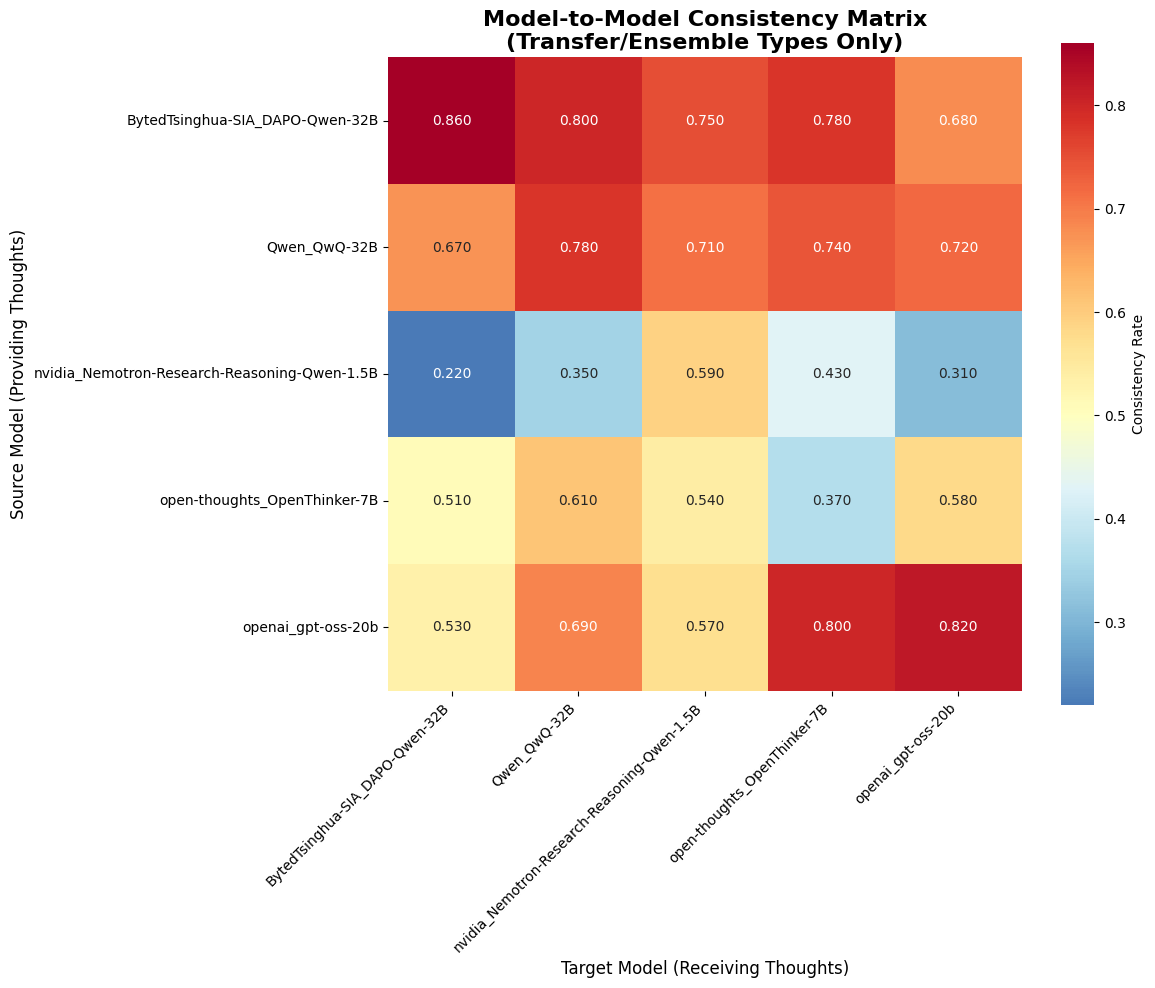

/tmp/ipykernel_45051/2311089949.py:299: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(consistency_by_type, labels=sorted_thought_types)


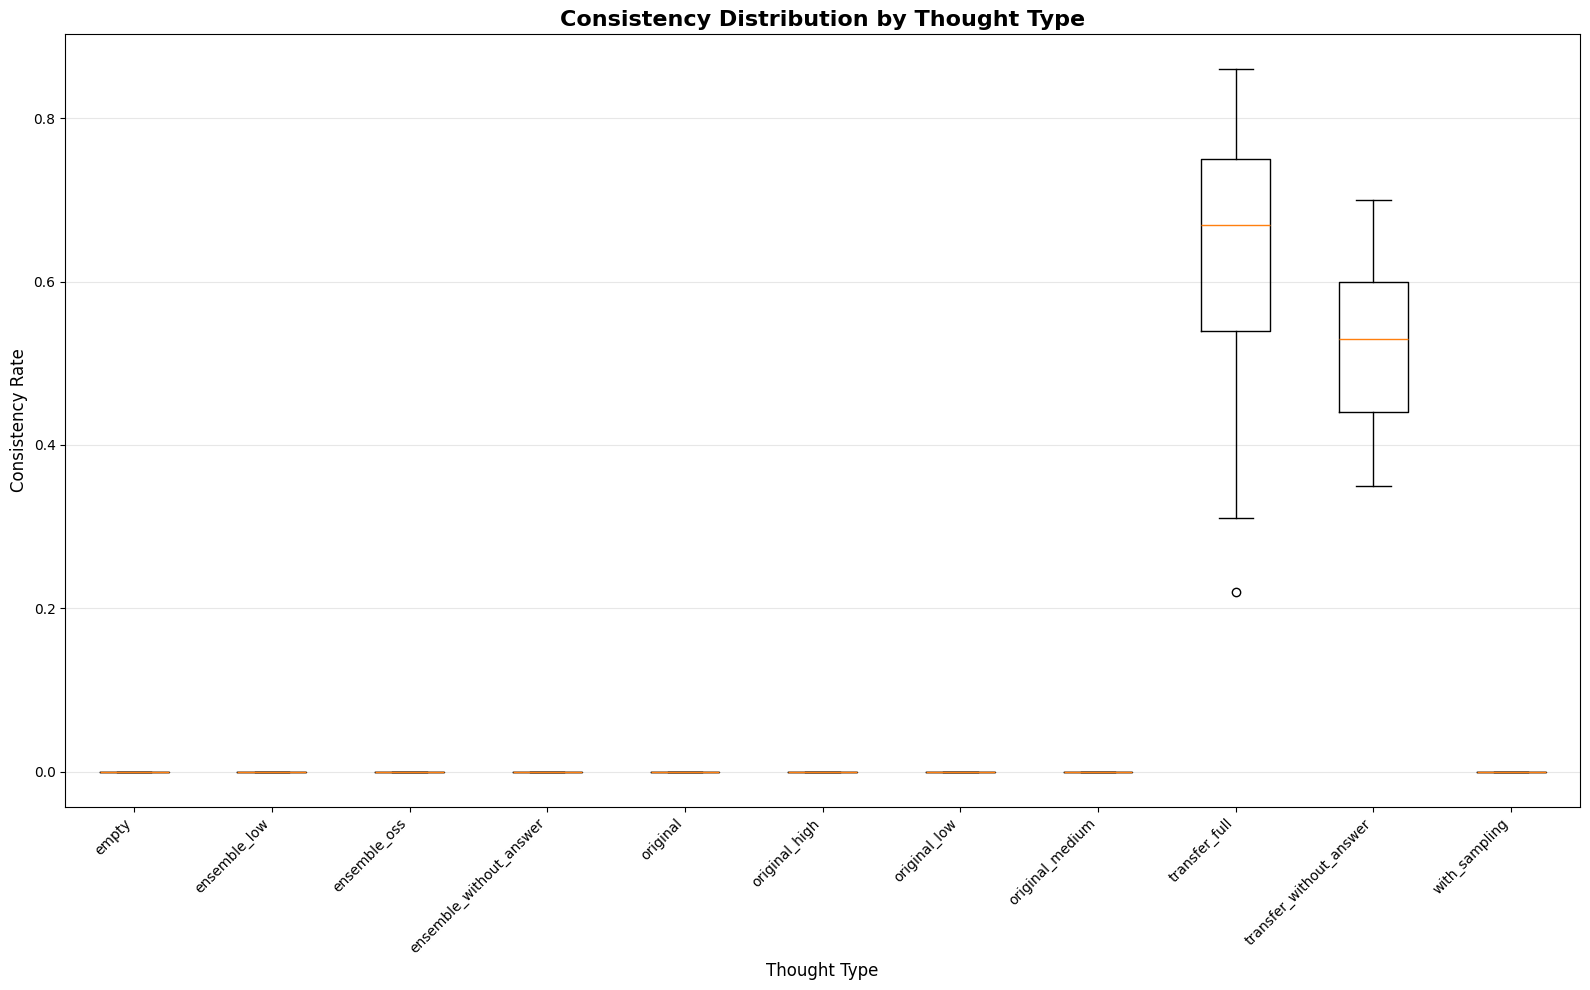

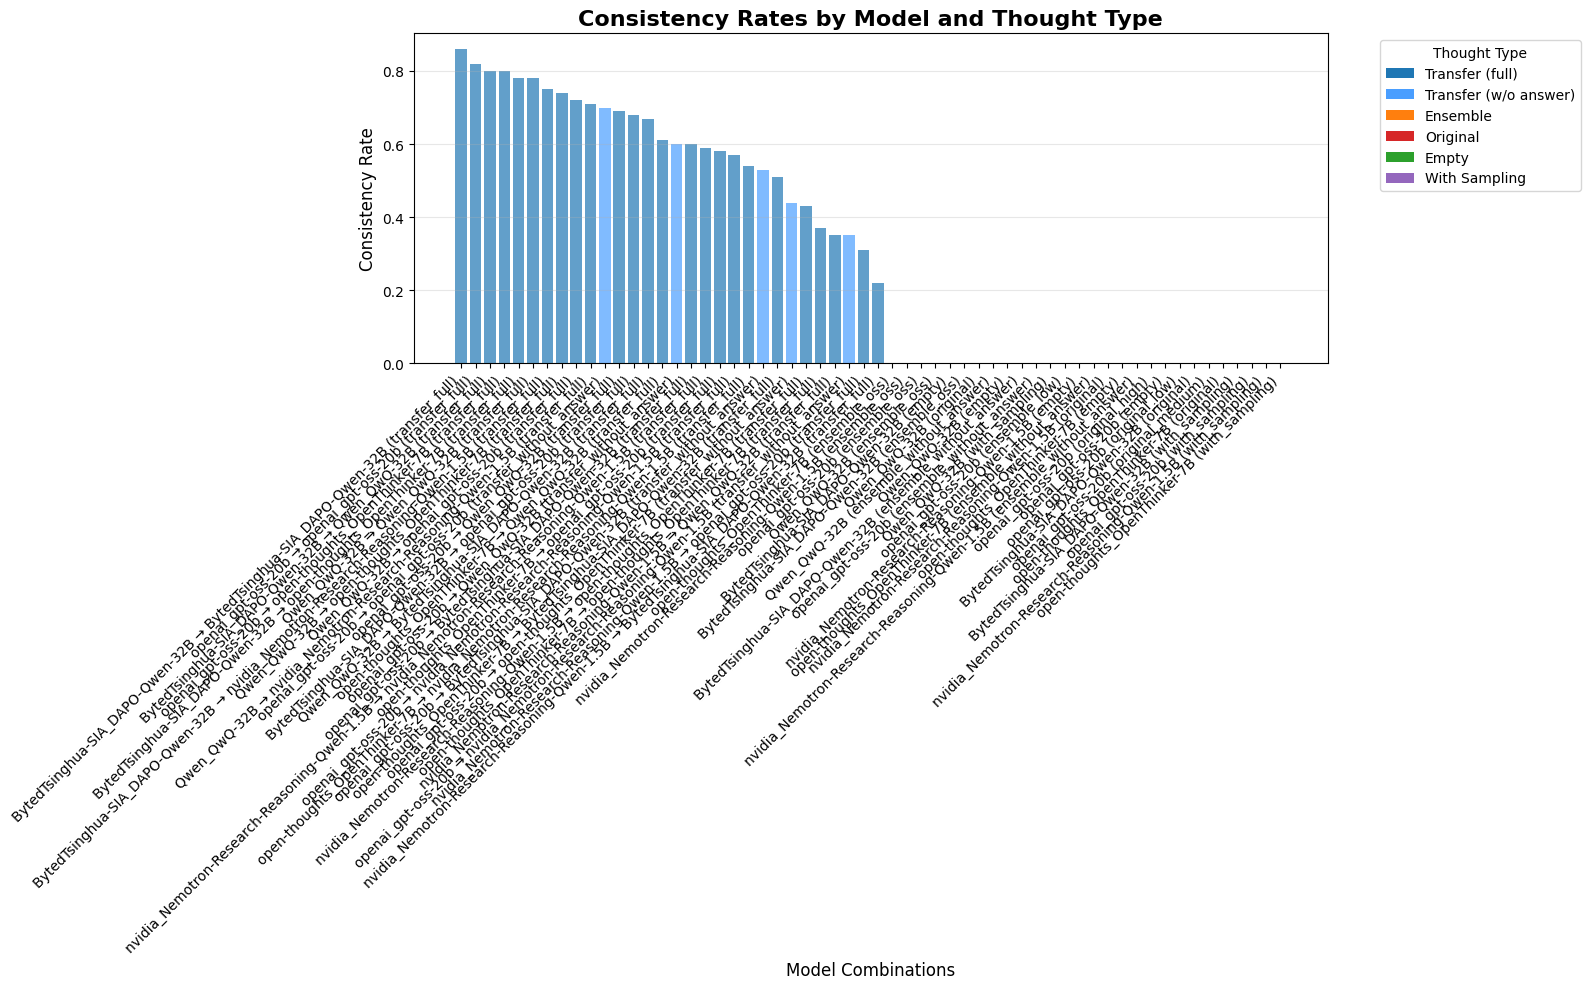

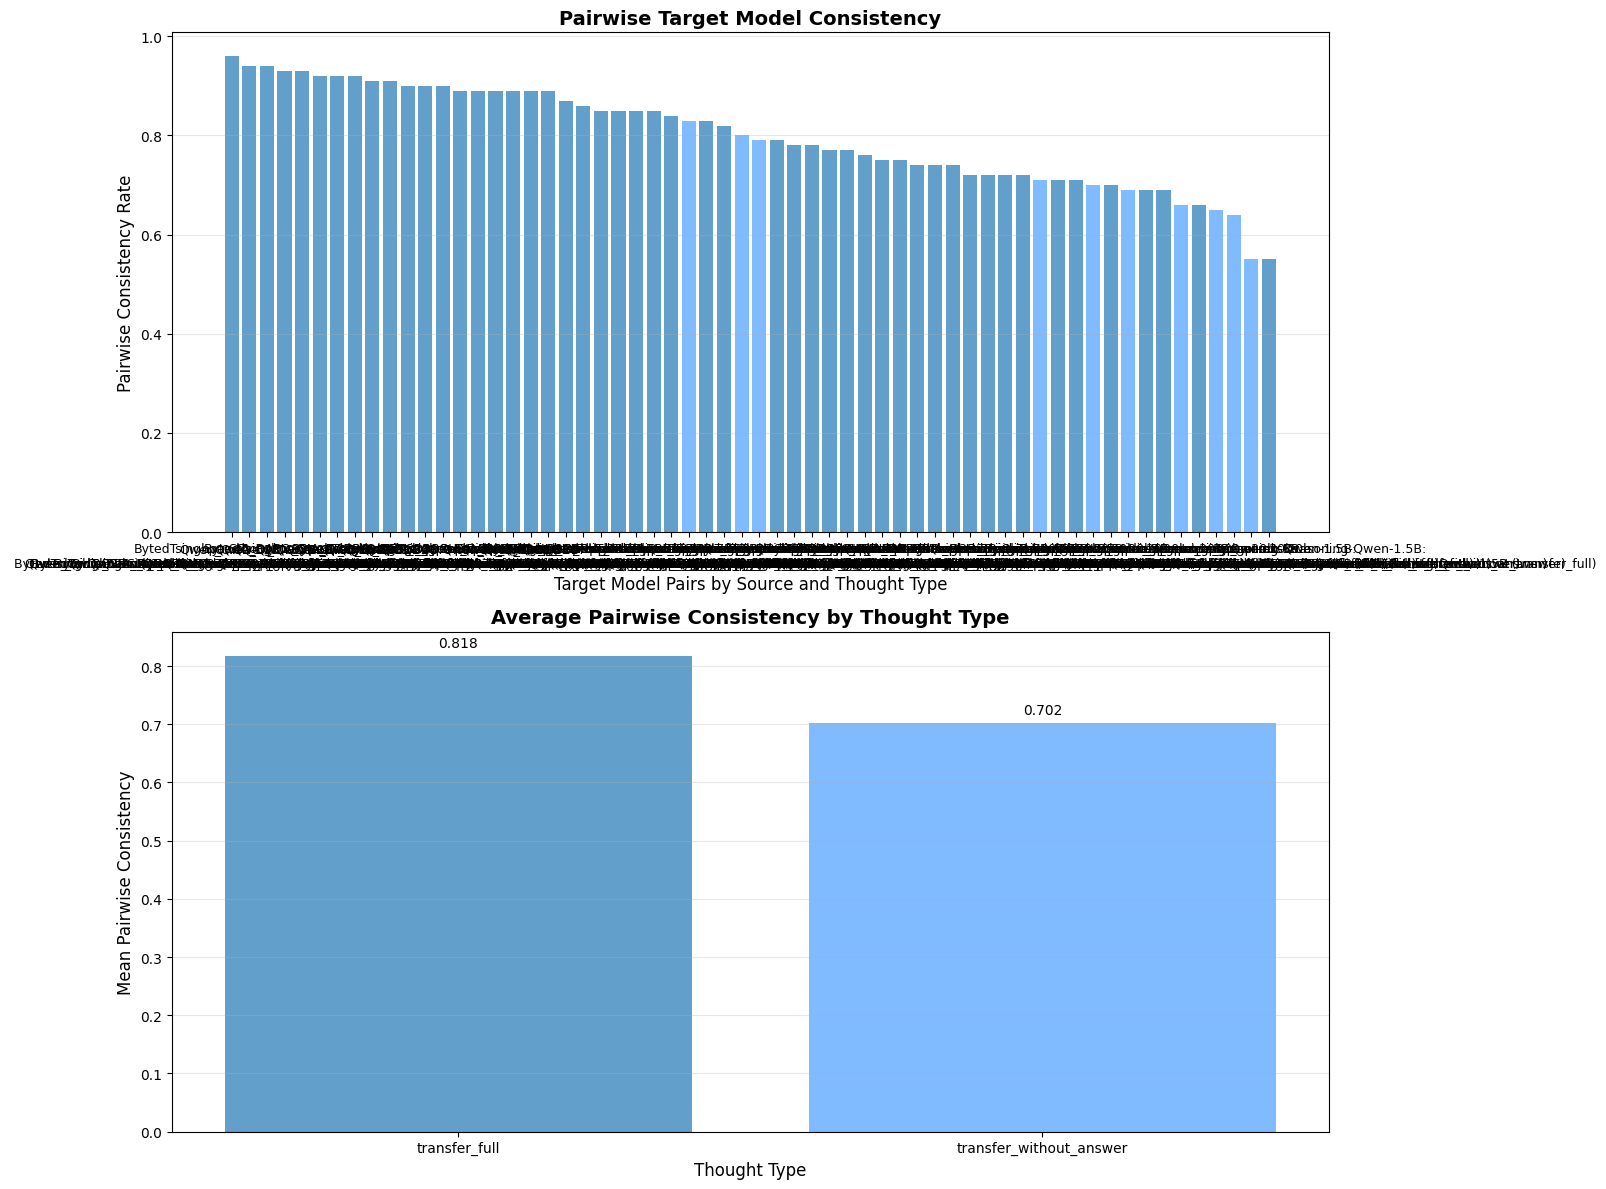


PAIRWISE TARGET MODEL CONSISTENCY
BytedTsinghua-SIA_DAPO-Qwen-32B: BytedTsinghua-SIA_DAPO-Qwen-32B vs Qwen_QwQ-32B (transfer_full) = 0.940 (94/100)
BytedTsinghua-SIA_DAPO-Qwen-32B: BytedTsinghua-SIA_DAPO-Qwen-32B vs nvidia_Nemotron-Research-Reasoning-Qwen-1.5B (transfer_full) = 0.890 (89/100)
BytedTsinghua-SIA_DAPO-Qwen-32B: BytedTsinghua-SIA_DAPO-Qwen-32B vs open-thoughts_OpenThinker-7B (transfer_full) = 0.920 (92/100)
BytedTsinghua-SIA_DAPO-Qwen-32B: BytedTsinghua-SIA_DAPO-Qwen-32B vs openai_gpt-oss-20b (transfer_full) = 0.780 (78/100)
BytedTsinghua-SIA_DAPO-Qwen-32B: Qwen_QwQ-32B vs nvidia_Nemotron-Research-Reasoning-Qwen-1.5B (transfer_full) = 0.890 (89/100)
BytedTsinghua-SIA_DAPO-Qwen-32B: Qwen_QwQ-32B vs open-thoughts_OpenThinker-7B (transfer_full) = 0.900 (90/100)
BytedTsinghua-SIA_DAPO-Qwen-32B: Qwen_QwQ-32B vs openai_gpt-oss-20b (transfer_full) = 0.780 (78/100)
BytedTsinghua-SIA_DAPO-Qwen-32B: nvidia_Nemotron-Research-Reasoning-Qwen-1.5B vs open-thoughts_OpenThinker-7B (trans

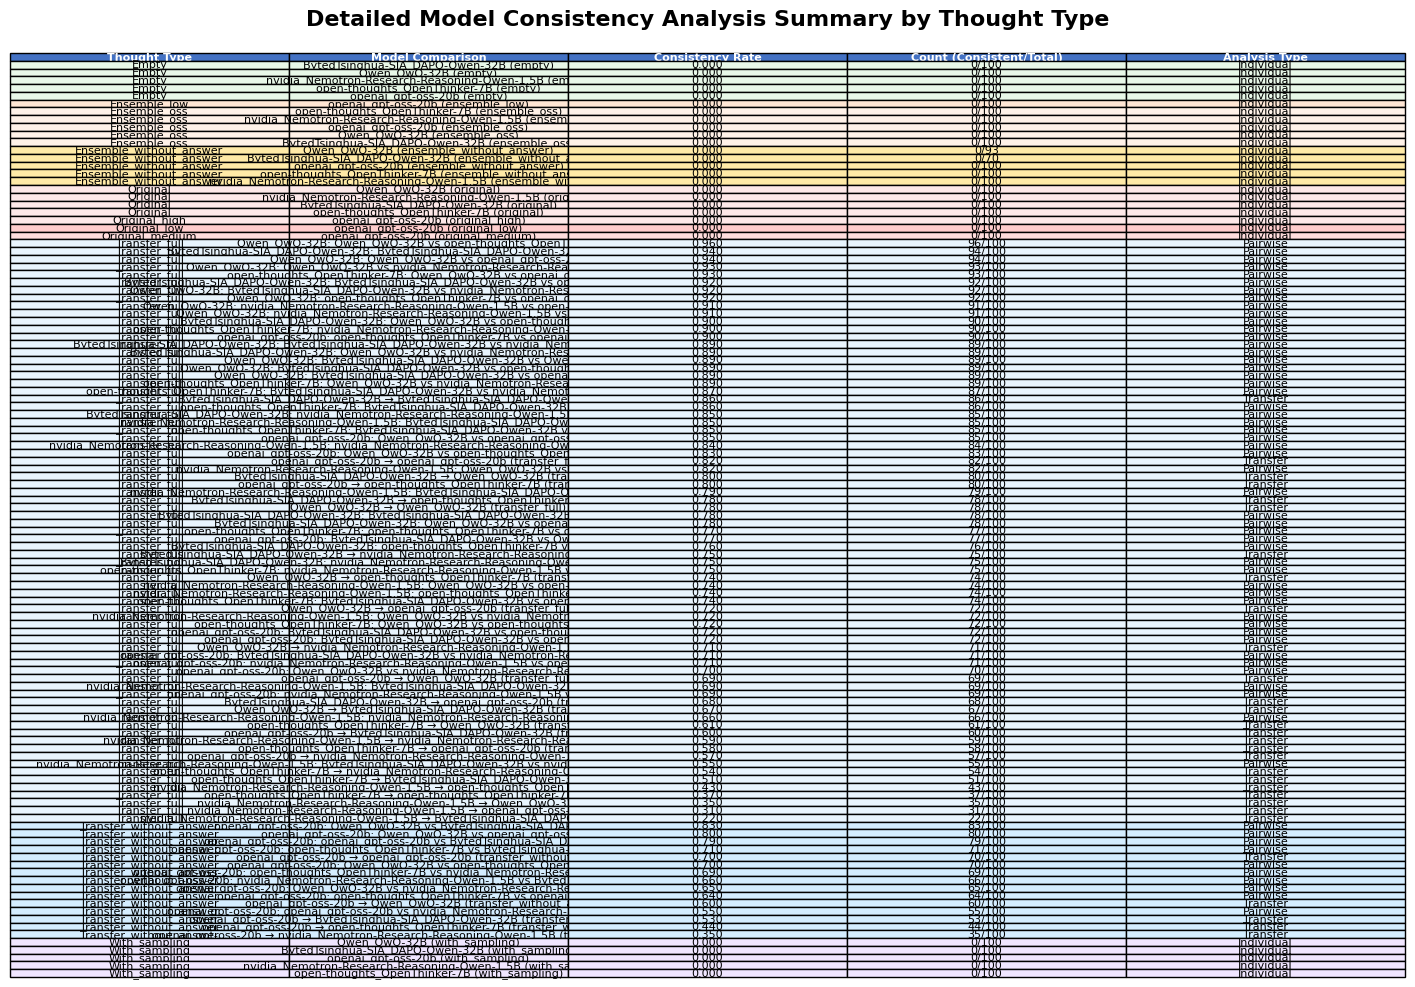


✓ All plots saved to: model_consistency_analysis.pdf

OVERALL CONSISTENCY ANALYSIS SUMMARY

EMPTY Type Statistics:
  Mean Consistency: 0.000
  Median Consistency: 0.000
  Std Dev: 0.000
  Count: 5

ENSEMBLE_LOW Type Statistics:
  Mean Consistency: 0.000
  Median Consistency: 0.000
  Std Dev: 0.000
  Count: 1

ENSEMBLE_OSS Type Statistics:
  Mean Consistency: 0.000
  Median Consistency: 0.000
  Std Dev: 0.000
  Count: 5

ENSEMBLE_WITHOUT_ANSWER Type Statistics:
  Mean Consistency: 0.000
  Median Consistency: 0.000
  Std Dev: 0.000
  Count: 5

ORIGINAL Type Statistics:
  Mean Consistency: 0.000
  Median Consistency: 0.000
  Std Dev: 0.000
  Count: 4

ORIGINAL_HIGH Type Statistics:
  Mean Consistency: 0.000
  Median Consistency: 0.000
  Std Dev: 0.000
  Count: 1

ORIGINAL_LOW Type Statistics:
  Mean Consistency: 0.000
  Median Consistency: 0.000
  Std Dev: 0.000
  Count: 1

ORIGINAL_MEDIUM Type Statistics:
  Mean Consistency: 0.000
  Median Consistency: 0.000
  Std Dev: 0.000
  Count: 1


In [8]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

def parse_jsonl_file(filepath):
    """Parse a JSONL file and return list of data points."""
    data_points = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    data = json.loads(line)
                    data_points.append(data)
                except json.JSONDecodeError as e:
                    print(f"Error parsing line in {filepath}: {e}")
                    continue
    
    return data_points

def check_consistency(data_point):
    """
    Check if two models are consistent on a data point.
    Returns 1 if consistent, 0 if not consistent.
    """
    llm_answer = data_point.get("LLM Answer", "")
    target_answer = data_point.get("Target Answer", "")
    
    # First check: exact match
    if llm_answer == target_answer:
        return 1
    
    # Second check: both results are "Correct"
    result = data_point.get("Result", "")
    target_result = data_point.get("Target Result", "")
    
    if result == "Correct" and target_result == "Correct":
        return 1
    
    return 0

def extract_model_names(filename):
    """Extract source model, target model (if applicable), and thought type from filename."""
    
    # Pattern 1: Transfer thoughts - {Model A}_thoughts_to_{Model B}_zero_shot_{version}.jsonl
    transfer_pattern = r'(.+)_thoughts_to_(.+)_zero_shot_(.+)\.jsonl'
    
    # Pattern 2: Individual model results - {Model A}_zero_shot_{thought_type}.jsonl
    individual_pattern = r'(.+)_zero_shot_(.+)\.jsonl'
    
    # Try transfer pattern first
    match = re.match(transfer_pattern, filename)
    if match:
        source_model = match.group(1)
        target_model = match.group(2)
        version = match.group(3)
        
        # Determine thought type based on version
        if version == "full":
            thought_type = "transfer_full"
        elif version == "without_answer":
            thought_type = "transfer_without_answer"
        else:
            thought_type = f"transfer_{version}"
            
        return source_model, target_model, thought_type
    
    # Try individual pattern
    match = re.match(individual_pattern, filename)
    if match:
        source_model = match.group(1)
        target_model = None  # No target model for individual results
        thought_type_raw = match.group(2)
        
        # Map the thought types based on your file patterns
        if thought_type_raw == "empty":
            thought_type = "empty"
        elif thought_type_raw == "original":
            thought_type = "original"
        elif thought_type_raw.startswith("original_"):
            # Handle original_high, original_low, original_medium
            thought_type = thought_type_raw
        elif thought_type_raw == "with_sampling":
            thought_type = "with_sampling"
        elif thought_type_raw.startswith("ensembled_thought_gen"):
            # Handle ensemble variations
            thought_type = "ensemble_" + thought_type_raw.split("_")[-1]  # Get the last part
        elif thought_type_raw.startswith("ensembled_thought_without_answer"):
            thought_type = "ensemble_without_answer"
        else:
            thought_type = thought_type_raw
            
        return source_model, target_model, thought_type
    
    return None, None, None

def calculate_consistency_matrix(folder_path):
    """
    Calculate consistency matrix for all model pairs.
    Returns consistency matrix, model names, and raw data for pairwise analysis.
    """
    consistency_data = {}
    model_names = set()
    data_by_source = {}  # Store raw data points for pairwise analysis
    thought_types = set()
    
    # Process all JSONL files in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith('.jsonl'):
            source_model, target_model, thought_type = extract_model_names(filename)
            
            if source_model and thought_type:
                model_names.add(source_model)
                thought_types.add(thought_type)
                
                # For transfer/ensemble, add target model
                if target_model:
                    model_names.add(target_model)
                
                filepath = os.path.join(folder_path, filename)
                data_points = parse_jsonl_file(filepath)
                
                if data_points:
                    # Create a unique key that includes thought type
                    if target_model:
                        key = (source_model, target_model, thought_type)
                        display_name = f"{source_model} → {target_model} ({thought_type})"
                    else:
                        key = (source_model, thought_type)
                        display_name = f"{source_model} ({thought_type})"
                    
                    # Store raw data for pairwise analysis
                    data_by_source[key] = data_points
                    
                    # Calculate consistency
                    consistent_count = sum(check_consistency(dp) for dp in data_points)
                    total_count = len(data_points)
                    consistency_rate = consistent_count / total_count if total_count > 0 else 0
                    
                    consistency_data[key] = {
                        'consistency_rate': consistency_rate,
                        'consistent_count': consistent_count,
                        'total_count': total_count,
                        'thought_type': thought_type,
                        'source_model': source_model,
                        'target_model': target_model,
                        'display_name': display_name
                    }
                    
                    print(f"{display_name}: {consistency_rate:.3f} ({consistent_count}/{total_count})")
    
    return consistency_data, sorted(list(model_names)), data_by_source, sorted(list(thought_types))

def create_consistency_matrix(consistency_data, model_names):
    """Create a matrix for visualization - only for transfer/ensemble types with both source and target."""
    n_models = len(model_names)
    matrix = np.zeros((n_models, n_models))
    
    model_to_idx = {model: idx for idx, model in enumerate(model_names)}
    
    # Only include transfer/ensemble entries that have both source and target
    for key, data in consistency_data.items():
        source = data['source_model']
        target = data['target_model']
        
        # Skip entries without target models (empty/original)
        if target is None:
            continue
            
        if source in model_to_idx and target in model_to_idx:
            i = model_to_idx[source]
            j = model_to_idx[target]
            matrix[i, j] = data['consistency_rate']
    
    return matrix

def calculate_pairwise_target_consistency(consistency_data, model_names, data_by_source):
    """
    Calculate pairwise consistency between target models for each source model and thought type.
    This compares how consistently two target models perform on the same data from a source.
    """
    pairwise_consistency = {}
    
    # Group by source model and thought type
    source_thought_groups = defaultdict(list)
    
    for key, data in consistency_data.items():
        source_model = data['source_model']
        target_model = data['target_model']
        thought_type = data['thought_type']
        
        # Only consider entries with target models
        if target_model:
            source_thought_groups[(source_model, thought_type)].append(target_model)
    
    # Compare pairs within each group
    for (source_model, thought_type), targets in source_thought_groups.items():
        if len(targets) < 2:
            continue
            
        # Compare each pair of target models
        for i in range(len(targets)):
            for j in range(i + 1, len(targets)):
                target_a = targets[i]
                target_b = targets[j]
                
                # Get data for both target models from the same source and thought type
                key_a = (source_model, target_a, thought_type)
                key_b = (source_model, target_b, thought_type)
                
                if key_a in data_by_source and key_b in data_by_source:
                    data_a = data_by_source[key_a]
                    data_b = data_by_source[key_b]
                    
                    # Compare consistency for each data point
                    consistent_pairs = 0
                    total_pairs = min(len(data_a), len(data_b))
                    
                    for idx in range(total_pairs):
                        consistency_a = check_consistency(data_a[idx])
                        consistency_b = check_consistency(data_b[idx])
                        
                        # Both models are consistent (both get it right or both get it wrong)
                        if consistency_a == consistency_b:
                            consistent_pairs += 1
                    
                    if total_pairs > 0:
                        pairwise_rate = consistent_pairs / total_pairs
                        pairwise_key = (source_model, target_a, target_b, thought_type)
                        pairwise_consistency[pairwise_key] = {
                            'consistency_rate': pairwise_rate,
                            'consistent_pairs': consistent_pairs,
                            'total_pairs': total_pairs,
                            'thought_type': thought_type
                        }
    
    return pairwise_consistency

def plot_consistency_results(consistency_data, model_names, data_by_source, thought_types, save_plots=False, save_pdf=True):
    """Create comprehensive visualizations of consistency results."""
    
    # Initialize PDF if saving
    pdf_pages = None
    if save_pdf:
        pdf_pages = PdfPages('model_consistency_analysis.pdf')
    
    # 1. Heatmap of consistency matrix (only for transfer/ensemble with target models)
    plt.figure(figsize=(12, 10))
    consistency_matrix = create_consistency_matrix(consistency_data, model_names)
    
    # Create heatmap
    mask = consistency_matrix == 0  # Mask cells with no data
    sns.heatmap(consistency_matrix, 
                xticklabels=model_names, 
                yticklabels=model_names,
                annot=True, 
                fmt='.3f', 
                cmap='RdYlBu_r',
                center=0.5,
                square=True,
                mask=mask,
                cbar_kws={'label': 'Consistency Rate'})
    
    plt.title('Model-to-Model Consistency Matrix\n(Transfer/Ensemble Types Only)', fontsize=16, fontweight='bold')
    plt.xlabel('Target Model (Receiving Thoughts)', fontsize=12)
    plt.ylabel('Source Model (Providing Thoughts)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('consistency_heatmap.png', dpi=300, bbox_inches='tight')
    if pdf_pages:
        pdf_pages.savefig(plt.gcf(), bbox_inches='tight')
    plt.show()
    
    # 2. Bar plot of consistency by thought type
    plt.figure(figsize=(16, 10))
    
    # Group by thought type
    thought_type_data = defaultdict(list)
    for key, data in consistency_data.items():
        thought_type = data['thought_type']
        thought_type_data[thought_type].append(data['consistency_rate'])
    
    # Sort thought types for better visualization
    sorted_thought_types = sorted(thought_type_data.keys())
    
    # Create box plot by thought type
    consistency_by_type = [thought_type_data[tt] for tt in sorted_thought_types]
    
    plt.boxplot(consistency_by_type, labels=sorted_thought_types)
    plt.xlabel('Thought Type', fontsize=12)
    plt.ylabel('Consistency Rate', fontsize=12)
    plt.title('Consistency Distribution by Thought Type', fontsize=16, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('consistency_by_thought_type.png', dpi=300, bbox_inches='tight')
    if pdf_pages:
        pdf_pages.savefig(plt.gcf(), bbox_inches='tight')
    plt.show()
    
    # 3. Detailed bar plot showing all combinations
    plt.figure(figsize=(16, 10))
    
    # Prepare data for plotting
    display_names = []
    consistency_rates = []
    colors = []
    
    # Color map for thought types - updated for your actual file patterns
    color_map = {
        'transfer_full': '#1f77b4', 
        'transfer_without_answer': '#4a9eff',
        'empty': '#2ca02c', 
        'original': '#d62728',
        'original_high': '#d62728',
        'original_low': '#ff6b6b',
        'original_medium': '#ff9999',
        'with_sampling': '#9467bd',
        'ensemble_oss': '#ff7f0e',
        'ensemble_low': '#ffb366',
        'ensemble_without_answer': '#ffa500'
    }
    
    # Function to get color for any thought type
    def get_color(thought_type):
        if thought_type in color_map:
            return color_map[thought_type]
        # Handle other variations by using base type color
        if thought_type.startswith('transfer'):
            return '#1f77b4'
        elif thought_type.startswith('ensemble'):
            return '#ff7f0e'
        elif thought_type.startswith('original'):
            return '#d62728'
        elif 'empty' in thought_type:
            return '#2ca02c'
        return '#gray'
    
    for key, data in consistency_data.items():
        display_names.append(data['display_name'])
        consistency_rates.append(data['consistency_rate'])
        colors.append(get_color(data['thought_type']))
    
    # Sort by consistency rate
    sorted_data = sorted(zip(display_names, consistency_rates, colors), key=lambda x: x[1], reverse=True)
    display_names, consistency_rates, colors = zip(*sorted_data)
    
    bars = plt.bar(range(len(display_names)), consistency_rates, color=colors, alpha=0.7)
    plt.xlabel('Model Combinations', fontsize=12)
    plt.ylabel('Consistency Rate', fontsize=12)
    plt.title('Consistency Rates by Model and Thought Type', fontsize=16, fontweight='bold')
    plt.xticks(range(len(display_names)), display_names, rotation=45, ha='right')
    
    # Add legend for thought types - updated for actual patterns
    unique_thought_types = set()
    for tt in thought_types:
        if tt.startswith('transfer'):
            unique_thought_types.add('transfer')
        elif tt.startswith('ensemble'):
            unique_thought_types.add('ensemble')
        elif tt.startswith('original'):
            unique_thought_types.add('original')
        elif tt == 'empty':
            unique_thought_types.add('empty')
        elif tt == 'with_sampling':
            unique_thought_types.add('with_sampling')
    
    from matplotlib.patches import Patch
    legend_elements = []
    if 'transfer' in unique_thought_types:
        legend_elements.append(Patch(facecolor=color_map['transfer_full'], label='Transfer (full)'))
        if 'transfer_without_answer' in [data['thought_type'] for data in consistency_data.values()]:
            legend_elements.append(Patch(facecolor=color_map['transfer_without_answer'], label='Transfer (w/o answer)'))
    if 'ensemble' in unique_thought_types:
        legend_elements.append(Patch(facecolor=color_map['ensemble_oss'], label='Ensemble'))
    if 'original' in unique_thought_types:
        legend_elements.append(Patch(facecolor=color_map['original'], label='Original'))
    if 'empty' in unique_thought_types:
        legend_elements.append(Patch(facecolor=color_map['empty'], label='Empty'))
    if 'with_sampling' in unique_thought_types:
        legend_elements.append(Patch(facecolor=color_map['with_sampling'], label='With Sampling'))
        
    plt.legend(handles=legend_elements, title='Thought Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    if save_plots:
        plt.savefig('consistency_all_combinations.png', dpi=300, bbox_inches='tight')
    if pdf_pages:
        pdf_pages.savefig(plt.gcf(), bbox_inches='tight')
    plt.show()
    
    # 4. Pairwise Target Model Consistency Analysis (only for transfer/ensemble)
    pairwise_consistency = calculate_pairwise_target_consistency(consistency_data, model_names, data_by_source)
    
    if pairwise_consistency:
        # Create visualization for pairwise target consistency
        fig, axes = plt.subplots(2, 1, figsize=(16, 12))
        
        # 4a. Bar plot of pairwise consistency
        pairwise_display_names = []
        pairwise_rates = []
        pairwise_colors = []
        
        for (source, target_a, target_b, thought_type), data in pairwise_consistency.items():
            display_name = f"{source}: {target_a} vs {target_b} ({thought_type})"
            pairwise_display_names.append(display_name)
            pairwise_rates.append(data['consistency_rate'])
            pairwise_colors.append(get_color(thought_type))
        
        # Sort by consistency rate
        sorted_pairwise = sorted(zip(pairwise_display_names, pairwise_rates, pairwise_colors), 
                                key=lambda x: x[1], reverse=True)
        pairwise_display_names, pairwise_rates, pairwise_colors = zip(*sorted_pairwise)
        
        bars = axes[0].bar(range(len(pairwise_display_names)), pairwise_rates, 
                          color=pairwise_colors, alpha=0.7)
        axes[0].set_xlabel('Target Model Pairs by Source and Thought Type', fontsize=12)
        axes[0].set_ylabel('Pairwise Consistency Rate', fontsize=12)
        axes[0].set_title('Pairwise Target Model Consistency', fontsize=14, fontweight='bold')
        axes[0].set_xticks(range(len(pairwise_display_names)))
        axes[0].set_xticklabels([name.split(':')[0] + ':\n' + name.split(':')[1] 
                                for name in pairwise_display_names], 
                               rotation=0, ha='center', fontsize=9)
        axes[0].grid(axis='y', alpha=0.3)
        
        # 4b. Summary statistics by thought type
        pairwise_by_thought_type = defaultdict(list)
        for (source, target_a, target_b, thought_type), data in pairwise_consistency.items():
            pairwise_by_thought_type[thought_type].append(data['consistency_rate'])
        
        thought_types_pairwise = list(pairwise_by_thought_type.keys())
        mean_values = [np.mean(pairwise_by_thought_type[tt]) for tt in thought_types_pairwise]
        
        bars = axes[1].bar(thought_types_pairwise, mean_values, 
                          color=[get_color(tt) for tt in thought_types_pairwise], 
                          alpha=0.7)
        axes[1].set_xlabel('Thought Type', fontsize=12)
        axes[1].set_ylabel('Mean Pairwise Consistency', fontsize=12)
        axes[1].set_title('Average Pairwise Consistency by Thought Type', fontsize=14, fontweight='bold')
        axes[1].grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, mean_values):
            axes[1].text(bar.get_x() + bar.get_width()/2., value + 0.01,
                        f'{value:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        
        if save_plots:
            plt.savefig('pairwise_target_consistency.png', dpi=300, bbox_inches='tight')
        if pdf_pages:
            pdf_pages.savefig(fig, bbox_inches='tight')
        plt.show()
        
        # Print pairwise consistency summary
        print("\n" + "="*60)
        print("PAIRWISE TARGET MODEL CONSISTENCY")
        print("="*60)
        
        for (source, target_a, target_b, thought_type), data in pairwise_consistency.items():
            print(f"{source}: {target_a} vs {target_b} ({thought_type}) = {data['consistency_rate']:.3f} "
                  f"({data['consistent_pairs']}/{data['total_pairs']})")
    
    # 5. Create a detailed summary table plot
    fig, ax = plt.subplots(figsize=(18, 12))
    ax.axis('tight')
    ax.axis('off')
    
    # Create summary table data
    summary_data = []
    
    # Add all consistency data
    for key, data in consistency_data.items():
        summary_data.append([
            data['thought_type'].capitalize(),
            data['display_name'],
            f"{data['consistency_rate']:.3f}",
            f"{data['consistent_count']}/{data['total_count']}",
            'Individual' if data['target_model'] is None else 'Transfer'
        ])
    
    # Add pairwise data if available
    if pairwise_consistency:
        for (source, target_a, target_b, thought_type), data in pairwise_consistency.items():
            display_name = f"{source}: {target_a} vs {target_b}"
            summary_data.append([
                thought_type.capitalize(),
                display_name,
                f"{data['consistency_rate']:.3f}",
                f"{data['consistent_pairs']}/{data['total_pairs']}",
                'Pairwise'
            ])
    
    # Create table
    table_df = pd.DataFrame(summary_data, 
                           columns=['Thought Type', 'Model Comparison', 'Consistency Rate', 
                                   'Count (Consistent/Total)', 'Analysis Type'])
    
    # Sort by thought type and consistency rate
    table_df = table_df.sort_values(['Thought Type', 'Consistency Rate'], ascending=[True, False])
    
    table = ax.table(cellText=table_df.values,
                    colLabels=table_df.columns,
                    cellLoc='center',
                    loc='center',
                    bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.8)
    
    # Color code the rows by thought type - updated for actual patterns
    def get_table_color(thought_type):
        color_mapping = {
            'transfer_full': '#E8F4FD',
            'transfer_without_answer': '#D4EDFF',
            'ensemble_oss': '#FFF2E8',
            'ensemble_low': '#FFE6D4',
            'ensemble_without_answer': '#FFEAA7',
            'empty': '#E8F8E8', 
            'original': '#FDE8E8',
            'original_high': '#FDE8E8',
            'original_low': '#FFCCCC',
            'original_medium': '#FFDDDD',
            'with_sampling': '#F0E6FF'
        }
        if thought_type.lower() in color_mapping:
            return color_mapping[thought_type.lower()]
        # Handle other versions
        if thought_type.lower().startswith('transfer'):
            return '#E8F4FD'
        elif thought_type.lower().startswith('ensemble'):
            return '#FFF2E8'
        elif thought_type.lower().startswith('original'):
            return '#FDE8E8'
        elif 'empty' in thought_type.lower():
            return '#E8F8E8'
        return '#F0F0F0'
    
    for i in range(len(table_df)):
        thought_type = table_df.iloc[i]['Thought Type']
        color = get_table_color(thought_type)
        for j in range(len(table_df.columns)):
            table[(i+1, j)].set_facecolor(color)
    
    # Header styling
    for j in range(len(table_df.columns)):
        table[(0, j)].set_facecolor('#4472C4')
        table[(0, j)].set_text_props(weight='bold', color='white')
    
    plt.title('Detailed Model Consistency Analysis Summary by Thought Type', 
             fontsize=16, fontweight='bold', pad=20)
    
    if save_plots:
        plt.savefig('consistency_summary_table.png', dpi=300, bbox_inches='tight')
    if pdf_pages:
        pdf_pages.savefig(fig, bbox_inches='tight')
    plt.show()
    
    # Close PDF if saving
    if pdf_pages:
        pdf_pages.close()
        print(f"\n✓ All plots saved to: model_consistency_analysis.pdf")
    
    # 6. Overall Summary statistics
    print("\n" + "="*60)
    print("OVERALL CONSISTENCY ANALYSIS SUMMARY")
    print("="*60)
    
    # Statistics by thought type
    for thought_type in thought_types:
        type_data = [data['consistency_rate'] for data in consistency_data.values() 
                    if data['thought_type'] == thought_type]
        if type_data:
            print(f"\n{thought_type.upper()} Type Statistics:")
            print(f"  Mean Consistency: {np.mean(type_data):.3f}")
            print(f"  Median Consistency: {np.median(type_data):.3f}")
            print(f"  Std Dev: {np.std(type_data):.3f}")
            print(f"  Count: {len(type_data)}")
    
    # Overall statistics
    all_consistency_rates = [data['consistency_rate'] for data in consistency_data.values()]
    print(f"\nOverall Statistics:")
    print(f"  Mean Consistency: {np.mean(all_consistency_rates):.3f}")
    print(f"  Median Consistency: {np.median(all_consistency_rates):.3f}")
    print(f"  Std Dev: {np.std(all_consistency_rates):.3f}")
    print(f"  Min Consistency: {np.min(all_consistency_rates):.3f}")
    print(f"  Max Consistency: {np.max(all_consistency_rates):.3f}")
    
    print(f"\nTotal Combinations Analyzed: {len(consistency_data)}")
    print(f"Number of Models: {len(model_names)}")
    print(f"Number of Thought Types: {len(thought_types)}")
    print(f"Models: {', '.join(model_names)}")
    print(f"Thought Types: {', '.join(thought_types)}")
    
    return consistency_matrix, table_df, pairwise_consistency

# Main execution
def main(folder_path):
    """Main function to run the consistency analysis."""
    
    print("Starting Model Consistency Analysis with Thought Types...")
    print(f"Analyzing folder: {folder_path}")
    print("-" * 50)
    
    # Calculate consistency data
    consistency_data, model_names, data_by_source, thought_types = calculate_consistency_matrix(folder_path)
    
    if not consistency_data:
        print("No valid JSONL files found with the expected naming patterns.")
        print("Expected patterns:")
        print("  Transfer thoughts: {Model A}_thoughts_to_{Model B}_zero_shot_{version}.jsonl")
        print("  Individual results: {Model A}_zero_shot_{thought_type}.jsonl")
        print("  Examples:")
        print("    - BytedTsinghua-SIA_DAPO-Qwen-32B_thoughts_to_Qwen_QwQ-32B_zero_shot_full.jsonl")
        print("    - openai_gpt-oss-20b_thoughts_to_nvidia_Nemotron_zero_shot_without_answer.jsonl")
        print("    - BytedTsinghua-SIA_DAPO-Qwen-32B_zero_shot_empty.jsonl")
        print("    - openai_gpt-oss-20b_zero_shot_original_high.jsonl")
        print("    - Qwen_QwQ-32B_zero_shot_ensembled_thought_gen_qwq_dapo_eval_oss.jsonl")
        return
    
    print(f"\nFound {len(consistency_data)} combinations")
    print(f"Thought types found: {', '.join(thought_types)}")
    print("-" * 50)
    
    # Create visualizations
    consistency_matrix, summary_df, pairwise_data = plot_consistency_results(
        consistency_data, model_names, data_by_source, thought_types, save_plots=True, save_pdf=True)
    
    return consistency_data, consistency_matrix, model_names, pairwise_data, thought_types

# Example usage:
if __name__ == "__main__":
    # Replace with your folder path
    folder_path = "../outputs"  # Update this path
    
    # Run the analysis
    results = main(folder_path)
    if results:
        consistency_data, matrix, models, pairwise_data, thought_types = results